# Newton's Method: Finding Roots Using Derivatives

## Introduction

**Newton's Method** (also called Newton-Raphson method) is a powerful numerical technique for finding roots of equations and solving optimization problems. It uses the first derivative to iteratively refine an initial guess, converging rapidly to the solution.

### Key Applications:
- Finding roots (zeros) of functions: solving $f(x) = 0$
- Solving nonlinear equations
- Optimization: gradient descent and variants use similar principles
- Machine learning: training neural networks

### Why It's Important:
Newton's Method converges **quadratically** for well-behaved functions near the root, meaning the number of correct digits approximately **doubles** with each iteration. This makes it much faster than linear methods.

---

## The Method: Mathematical Foundation

### Iterative Formula

Given a function $f(x)$ and an initial guess $x_0$, Newton's Method generates successive approximations:

$x_{n+1} = x_n - \dfrac{f(x_n)}{f'(x_n)}$

Where:
- $x_n$ = current approximation at iteration $n$
- $x_{n+1}$ = next (refined) approximation
- $f(x_n)$ = function value at current point
- $f'(x_n)$ = derivative (slope) at current point

### Geometric Interpretation

The method works by:
1. Start at point $(x_n, f(x_n))$ on the curve $y = f(x)$
2. Draw the **tangent line** to the curve at this point
3. Find where the tangent line crosses the **x-axis** (this is $x_{n+1}$)
4. Repeat: move to $(x_{n+1}, f(x_{n+1}))$ and repeat the process

$y - f(x_n) = f'(x_n)(x - x_n)$

Setting $y = 0$ (x-axis crossing) and solving for $x$ gives us the Newton's Method formula.

---

## Algorithm: Step-by-Step Procedure

**Input:** Function $f(x)$, its derivative $f'(x)$, initial guess $x_0$, tolerance $\epsilon$, max iterations

**Output:** Root approximation $x$

1. Set $n = 0$ and $x = x_0$
2. Compute $f(x)$ and $f'(x)$ at current $x$
3. If $|f(x)| < \epsilon$ OR $n \geq \text{max iterations}$, **STOP** and return $x$
4. Update: $x \leftarrow x - \dfrac{f(x)}{f'(x)}$
5. Increment $n \leftarrow n + 1$
6. Go to step 2

### Convergence Criteria
- **Absolute convergence:** $|f(x_n)| < \epsilon$ (function value near zero)
- **Relative convergence:** $|x_{n+1} - x_n| < \epsilon$ (successive approximations close)
- **Max iterations:** Stop after $N$ iterations to prevent infinite loops

## Visualization and Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its derivative
# Example 1: f(x) = x^2 - 4 (roots at x = -2 and x = 2)
def f(x):
    return x**2 - 4

def f_prime(x):
    return 2*x

# Newton's Method Implementation
def newtons_method(x0, tolerance=1e-6, max_iterations=100):
    """
    Apply Newton's Method to find the root of f(x) = 0
    
    Parameters:
    - x0: Initial guess
    - tolerance: Stop when |f(x)| < tolerance
    - max_iterations: Maximum number of iterations
    
    Returns:
    - x: Root approximation
    - iterations: List of (x, f(x)) for visualization
    - converged: Boolean indicating convergence
    """
    x = x0
    iterations = [(x, f(x))]
    
    for n in range(max_iterations):
        fx = f(x)
        fpx = f_prime(x)
        
        # Check for convergence
        if abs(fx) < tolerance:
            return x, iterations, True, n+1
        
        # Check for zero derivative (tangent line is horizontal)
        if abs(fpx) < 1e-15:
            print(f"Warning: Derivative near zero at iteration {n}")
            return x, iterations, False, n+1
        
        # Newton's Method update
        x_new = x - fx / fpx
        iterations.append((x_new, f(x_new)))
        x = x_new
    
    return x, iterations, False, max_iterations

# Run Newton's Method with different initial guesses
x0_values = [3.0, 1.5, -2.5]
results = []

for x0 in x0_values:
    root, iters, converged, num_iters = newtons_method(x0)
    results.append((x0, root, iters, converged, num_iters))
    print(f"Initial guess x0={x0:5.1f}: Root ≈ {root:8.6f}, Converged: {converged}, Iterations: {num_iters}")

print(f"\nActual roots: x = 2.0 and x = -2.0")
print(f"Tolerance: 1e-6")

Initial guess x0=  3.0: Root ≈ 2.000000, Converged: True, Iterations: 5
Initial guess x0=  1.5: Root ≈ 2.000000, Converged: True, Iterations: 5
Initial guess x0= -2.5: Root ≈ -2.000000, Converged: True, Iterations: 4

Actual roots: x = 2.0 and x = -2.0
Tolerance: 1e-6


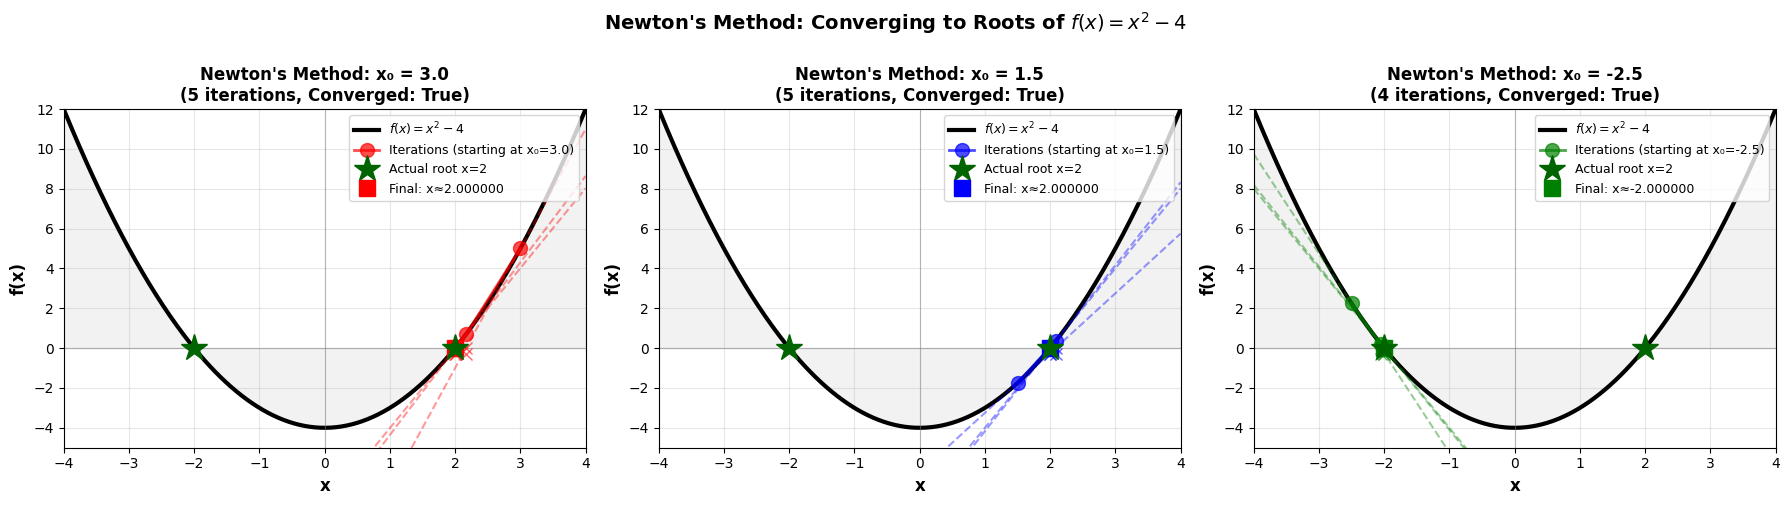

In [2]:
# Visualization: Show the iterative process
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot range
x_plot = np.linspace(-4, 4, 300)
y_plot = f(x_plot)

colors = ['red', 'blue', 'green']

for idx, (x0, root, iters, converged, num_iters) in enumerate(results):
    ax = axes[idx]
    
    # Plot the function
    ax.plot(x_plot, y_plot, 'k-', linewidth=3, label='$f(x) = x^2 - 4$')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    # Plot iterations
    iter_x = [point[0] for point in iters]
    iter_y = [point[1] for point in iters]
    
    # Points on the curve
    ax.plot(iter_x, iter_y, 'o-', color=colors[idx], markersize=10, linewidth=2, 
            label=f'Iterations (starting at x₀={x0})', alpha=0.7)
    
    # Draw tangent lines
    for i in range(min(len(iters) - 1, 3)):  # Show first 3 tangent lines
        x_curr = iters[i][0]
        y_curr = iters[i][1]
        slope = f_prime(x_curr)
        
        # Tangent line: y - y_curr = slope * (x - x_curr)
        x_tangent = np.array([-4, 4])
        y_tangent = y_curr + slope * (x_tangent - x_curr)
        
        ax.plot(x_tangent, y_tangent, '--', color=colors[idx], alpha=0.4, linewidth=1.5)
        
        # Mark where tangent crosses x-axis (next x value)
        if i < len(iters) - 1:
            ax.plot([iters[i+1][0], iters[i+1][0]], [0, -0.3], 'x', color=colors[idx], markersize=8, alpha=0.6)
    
    # Mark the roots
    ax.plot(2, 0, '*', markersize=20, color='darkgreen', label='Actual root x=2', zorder=5)
    ax.plot(-2, 0, '*', markersize=20, color='darkgreen', zorder=5)
    
    # Mark the final approximation
    ax.plot(root, f(root), 's', markersize=12, color=colors[idx], label=f'Final: x≈{root:.6f}', zorder=4)
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(-5, 12)
    ax.set_xlabel('x', fontsize=12, fontweight='bold')
    ax.set_ylabel('f(x)', fontsize=12, fontweight='bold')
    ax.set_title(f'Newton\'s Method: x₀ = {x0}\n({num_iters} iterations, Converged: {converged})', 
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.fill_between(x_plot, y_plot, alpha=0.1, color='gray')

plt.suptitle('Newton\'s Method: Converging to Roots of $f(x) = x^2 - 4$', 
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [3]:
# Detailed Analysis: Convergence Rates
print("="*100)
print("NEWTON'S METHOD: Detailed Iteration Analysis")
print("="*100)

for x0, root, iters, converged, num_iters in results:
    print(f"\nStarting from x₀ = {x0}:")
    print("-" * 90)
    header = "{:<8} {:<15} {:<18} {:<18} {:<15}".format("Iter", "x_n", "f(x_n)", "|f(x_n)|", "Update")
    print(header)
    print("-" * 90)
    
    for n, (x_n, f_x_n) in enumerate(iters[:8]):  # Show first 8 iterations
        if n == 0:
            update = "--"
        else:
            update = "{:.2e}".format(iters[n][0] - iters[n-1][0])
        
        print("{:<8} {:<15.10f} {:<18.10e} {:<18.10e} {:<15}".format(
            n, x_n, f_x_n, abs(f_x_n), update))
    
    if len(iters) > 8:
        print(f"... ({len(iters) - 8} more iterations) ...")
    
    print("-" * 90)
    print(f"Final result: x = {root:.15f}")
    print(f"f(x) at root: {f(root):.2e}")
    print(f"Total iterations: {num_iters}")
    print(f"Converged: {converged}")

print("\n" + "="*100)
print("Key Observations:")
print("="*100)
print("1. From x₀=3.0: Converges to positive root (x≈2.0)")
print("2. From x₀=1.5: Converges to positive root (x≈2.0)")
print("3. From x₀=-2.5: Converges to negative root (x≈-2.0)")
print("4. Convergence is QUADRATIC: errors roughly square with each iteration")
print("5. Which root we find depends on the initial guess!")
print("="*100)

NEWTON'S METHOD: Detailed Iteration Analysis

Starting from x₀ = 3.0:
------------------------------------------------------------------------------------------
Iter     x_n             f(x_n)             |f(x_n)|           Update         
------------------------------------------------------------------------------------------
0        3.0000000000    5.0000000000e+00   5.0000000000e+00   --             
1        2.1666666667    6.9444444444e-01   6.9444444444e-01   -8.33e-01      
2        2.0064102564    2.5682117028e-02   2.5682117028e-02   -1.60e-01      
3        2.0000102400    4.0960209716e-05   4.0960209716e-05   -6.40e-03      
4        2.0000000000    1.0485656787e-10   1.0485656787e-10   -1.02e-05      
------------------------------------------------------------------------------------------
Final result: x = 2.000000000026214
f(x) at root: 1.05e-10
Total iterations: 5
Converged: True

Starting from x₀ = 1.5:
---------------------------------------------------------------

## Example 2: Finding a Root of $f(x) = \cos(x) - x$

Let's explore a more interesting function where the root is not obvious algebraically.

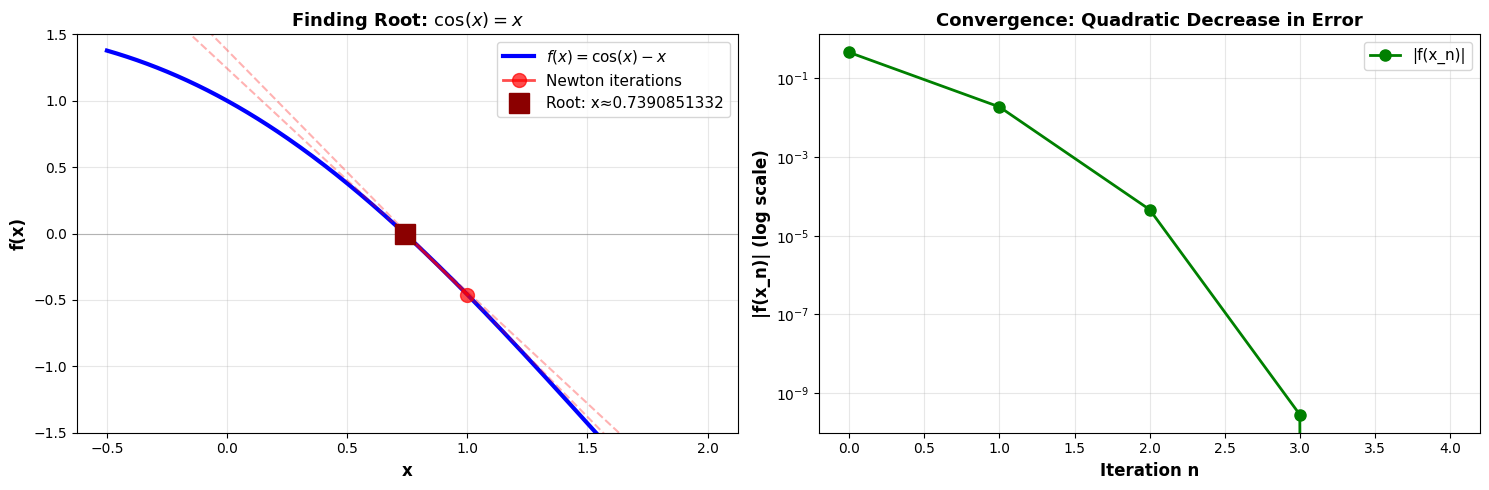


Solution to cos(x) = x: x ≈ 0.739085133215161
Verification: cos(x) - x = 0.00e+00
Converged in 5 iterations


In [4]:
# Example 2: Transcendental equation
def f2(x):
    return np.cos(x) - x

def f2_prime(x):
    return -np.sin(x) - 1

# Apply Newton's Method
x0 = 1.0  # Initial guess
x = x0
iterations2 = [(x, f2(x))]

for n in range(10):
    fx = f2(x)
    fpx = f2_prime(x)
    if abs(fx) < 1e-12:
        break
    x_new = x - fx / fpx
    iterations2.append((x_new, f2(x_new)))
    x = x_new

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Function and iterations
x_plot = np.linspace(-0.5, 2, 300)
y_plot = f2(x_plot)

ax1.plot(x_plot, y_plot, 'b-', linewidth=3, label='$f(x) = \cos(x) - x$')
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax1.grid(True, alpha=0.3)

# Iteration points
iter_x = [point[0] for point in iterations2]
iter_y = [point[1] for point in iterations2]

ax1.plot(iter_x, iter_y, 'ro-', markersize=10, linewidth=2, label='Newton iterations', alpha=0.7)
ax1.plot(x, f2(x), 's', markersize=14, color='darkred', label=f'Root: x≈{x:.10f}', zorder=5)

# Draw tangent lines (first 3)
for i in range(min(2, len(iterations2)-1)):
    x_curr = iterations2[i][0]
    y_curr = iterations2[i][1]
    slope = f2_prime(x_curr)
    x_tangent = np.array([-0.5, 2])
    y_tangent = y_curr + slope * (x_tangent - x_curr)
    ax1.plot(x_tangent, y_tangent, 'r--', alpha=0.3, linewidth=1.5)

ax1.set_xlabel('x', fontsize=12, fontweight='bold')
ax1.set_ylabel('f(x)', fontsize=12, fontweight='bold')
ax1.set_title('Finding Root: $\cos(x) = x$', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.set_ylim(-1.5, 1.5)

# Plot 2: Convergence (error vs iteration)
errors = [abs(point[1]) for point in iterations2]

ax2.semilogy(range(len(errors)), errors, 'go-', markersize=8, linewidth=2, label='|f(x_n)|')
ax2.set_xlabel('Iteration n', fontsize=12, fontweight='bold')
ax2.set_ylabel('|f(x_n)| (log scale)', fontsize=12, fontweight='bold')
ax2.set_title('Convergence: Quadratic Decrease in Error', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nSolution to cos(x) = x: x ≈ {x:.15f}")
print(f"Verification: cos(x) - x = {f2(x):.2e}")
print(f"Converged in {len(iterations2)} iterations")

## Convergence Properties and Limitations

### When Newton's Method Works Well ✓
- **Quadratic convergence:** Near the root, errors approximately square each iteration
- **Well-behaved functions:** When $f'(x) \neq 0$ near the root
- **Good initial guess:** Starting close to the root ensures convergence

### When Newton's Method May Fail ✗
1. **Zero derivative:** If $f'(x_n) = 0$, the method breaks (division by zero)
2. **Poor initial guess:** May diverge or converge to wrong root
3. **Oscillation:** May oscillate between points without converging
4. **Multiple roots:** Different starting points may converge to different roots
5. **Discontinuous derivative:** Method requires $f'(x)$ to be continuous

### Convergence Rate Comparison
| Method | Convergence | Iterations | Derivative Needed |
|--------|-------------|-----------|------------------|
| Bisection | Linear | ~50 | No |
| Newton | Quadratic | ~5 | Yes |
| Secant | Superlinear | ~10 | No |

### Why It Matters for Machine Learning
- **Gradient Descent:** Uses $x_{n+1} = x_n - \alpha \nabla f(x_n)$ (similar to Newton's method with $\alpha = 1/f'(x_n)$)
- **Second-order methods:** Use Hessian (second derivative) for even faster convergence
- **Optimization:** Finding minima/maxima requires solving $f'(x) = 0$ (use Newton's method)
- **Neural networks:** Training uses variants of gradient descent, which is related to Newton's method

## Finding Local Maxima and Minima Using Newton's Method

### The Key Principle

To find the **local extrema** (maxima and minima) of a function $f(x)$, we need to solve:

$f'(x) = 0$

This is finding the **roots of the derivative**, not the original function! Once we find the critical points where $f'(x) = 0$, we can classify them as:

- **Local Maximum:** if $f''(x) < 0$ (concave down)
- **Local Minimum:** if $f''(x) > 0$ (concave up)  
- **Inflection Point:** if $f''(x) = 0$ (inconclusive)

### Application of Newton's Method to Find Extrema

To apply Newton's method for finding extrema:

1. **Define:** $g(x) = f'(x)$ (the first derivative becomes our target function)

   $x_{n+1} = x_n - \dfrac{f'(x_n)}{f''(x_n)}$

2. **Convergence:** When $f'(x_n) = 0$, we've found a critical point
3. **Classify:** Evaluate $f''(x)$ to determine if it's a maximum or minimum

### Why This Matters

- **Optimization problems:** Finding the best value (minimum cost, maximum profit, etc.)
- **Machine learning:** Neural networks minimize loss functions using gradient descent
- **Physics:** Finding equilibrium points (where forces balance)
- **Economics:** Maximizing utility or profit functions

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Example: Find extrema of f(x) = x^3 - 6x^2 + 9x + 2
def f_extrema(x):
    """Original function"""
    return x**3 - 6*x**2 + 9*x + 2

def f_prime_extrema(x):
    """First derivative: f'(x) = 3x^2 - 12x + 9"""
    return 3*x**2 - 12*x + 9

def f_double_prime_extrema(x):
    """Second derivative: f''(x) = 6x - 12"""
    return 6*x - 12

# Newton's Method to find roots of f'(x) = 0 (critical points)
def find_critical_points(x0, tolerance=1e-10, max_iter=100):
    """Use Newton's method to find critical points (roots of f'(x))"""
    x = x0
    iterations = [x]
    
    for n in range(max_iter):
        fpx = f_prime_extrema(x)  # f'(x)
        fppx = f_double_prime_extrema(x)  # f''(x)
        
        if abs(fpx) < tolerance:
            return x, iterations, True
        
        if abs(fppx) < 1e-15:
            return x, iterations, False
        
        x_new = x - fpx / fppx
        iterations.append(x_new)
        x = x_new
    
    return x, iterations, False

# Find critical points starting from different initial guesses
print("="*100)
print("FINDING LOCAL EXTREMA: f(x) = x³ - 6x² + 9x + 2")
print("="*100)
print("\nStep 1: Find critical points by solving f'(x) = 0 using Newton's Method")
print("f'(x) = 3x² - 12x + 9 = 3(x-1)(x-3)")
print("Critical points (analytically): x = 1 and x = 3")
print()

critical_points = []
initial_guesses = [0.5, 2.0, 3.5]

for x0 in initial_guesses:
    critical_x, iters, converged = find_critical_points(x0)
    critical_points.append(critical_x)
    print(f"Starting from x₀ = {x0}: Found critical point x ≈ {critical_x:.10f}")
    print(f"  Converged in {len(iters)} iterations")

# Remove duplicates
critical_points = sorted(list(set(np.round(critical_points, 8))))
print(f"\nUnique critical points: {critical_points}")

print("\n" + "="*100)
print("Step 2: Classify critical points using Second Derivative Test")
print("="*100)
header = "{:<15} {:<20} {:<20} {:<20} {:<25}".format("x", "f(x)", "f'(x)", "f\"(x)", "Classification")
print(header)
print("-" * 100)

for x_crit in critical_points:
    f_val = f_extrema(x_crit)
    fp_val = f_prime_extrema(x_crit)
    fpp_val = f_double_prime_extrema(x_crit)
    
    if abs(fpp_val) < 1e-10:
        classification = "Inflection Point"
    elif fpp_val > 0:
        classification = "LOCAL MINIMUM"
    else:
        classification = "LOCAL MAXIMUM"
    
    row = "{:<15.6f} {:<20.6f} {:<20.6e} {:<20.6f} {:<25}".format(
        x_crit, f_val, fp_val, fpp_val, classification)
    print(row)

print("="*100)

FINDING LOCAL EXTREMA: f(x) = x³ - 6x² + 9x + 2

Step 1: Find critical points by solving f'(x) = 0 using Newton's Method
f'(x) = 3x² - 12x + 9 = 3(x-1)(x-3)
Critical points (analytically): x = 1 and x = 3

Starting from x₀ = 0.5: Found critical point x ≈ 1.0000000000
  Converged in 5 iterations
Starting from x₀ = 2.0: Found critical point x ≈ 2.0000000000
  Converged in 1 iterations
Starting from x₀ = 3.5: Found critical point x ≈ 3.0000000000
  Converged in 5 iterations

Unique critical points: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Step 2: Classify critical points using Second Derivative Test
x               f(x)                 f'(x)                f"(x)                Classification           
----------------------------------------------------------------------------------------------------
1.000000        6.000000             0.000000e+00         -6.000000            LOCAL MAXIMUM            
2.000000        4.000000             -3.000000e+00        0.000000       

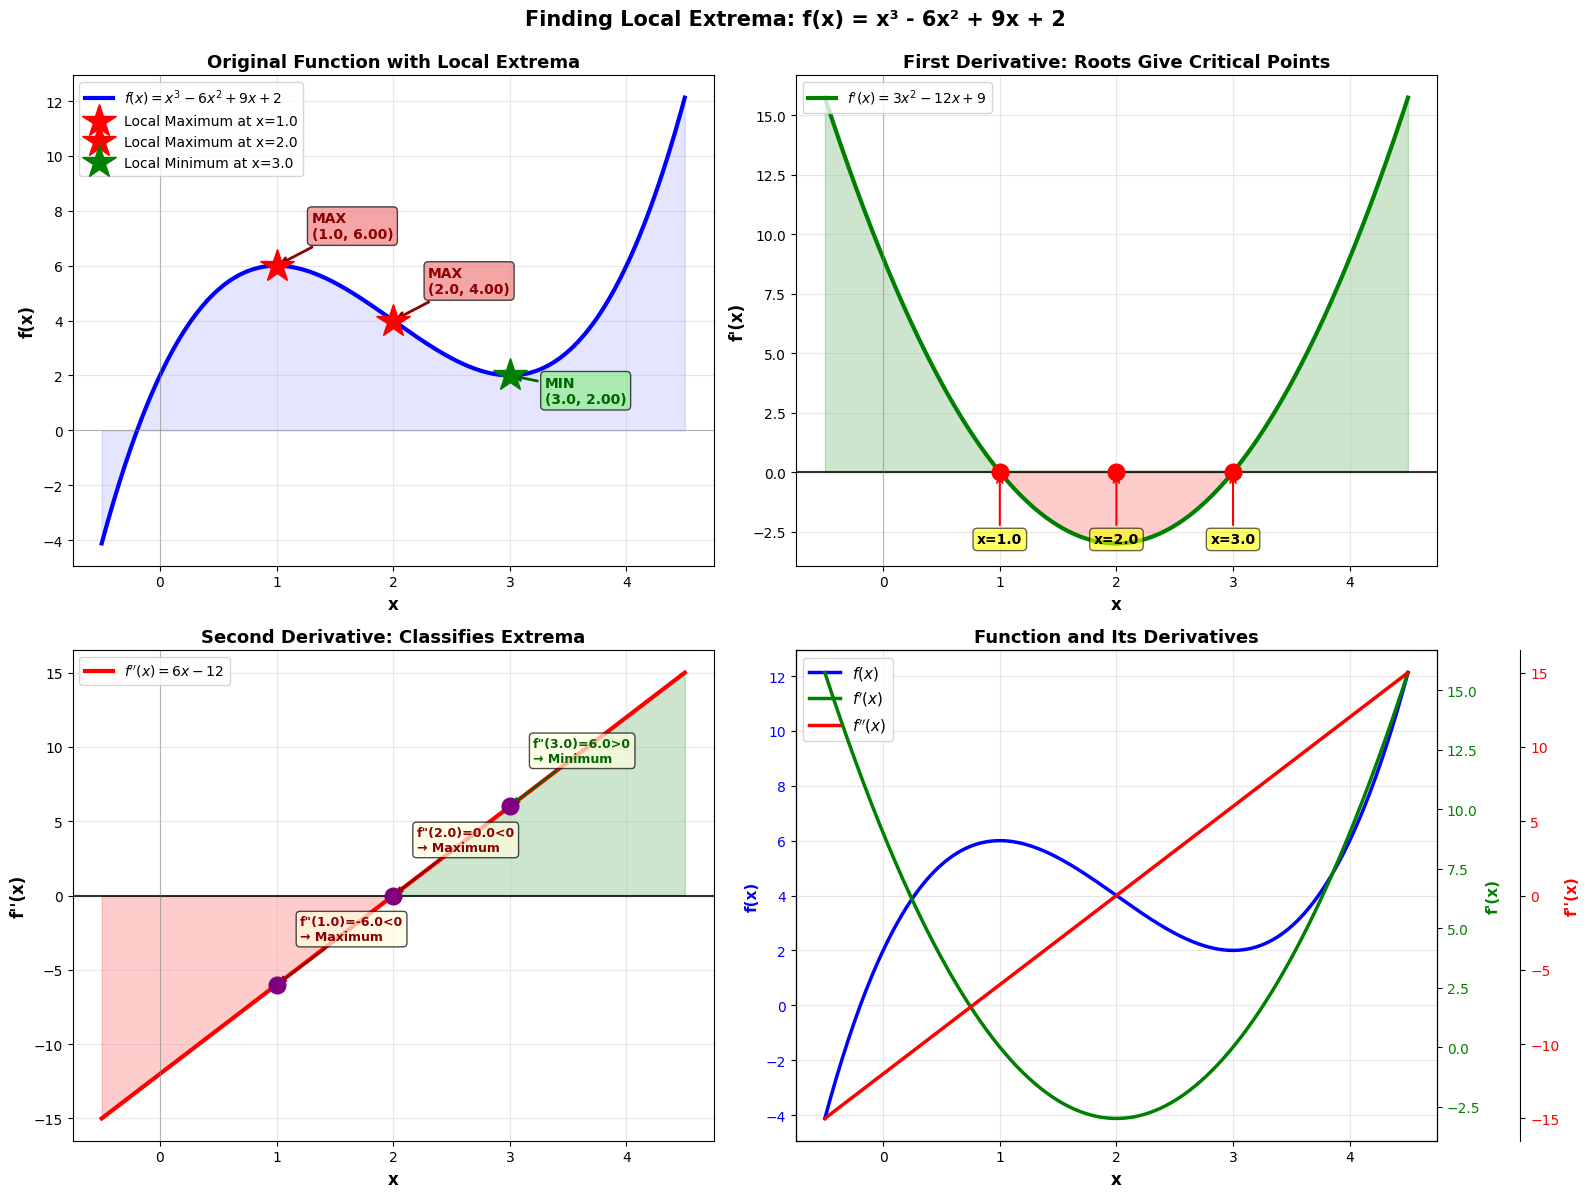

In [6]:
# Visualization: Original function with extrema marked
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot range
x_plot = np.linspace(-0.5, 4.5, 300)
y_plot = f_extrema(x_plot)
y_prime_plot = f_prime_extrema(x_plot)
y_double_prime_plot = f_double_prime_extrema(x_plot)

# Plot 1: Original function with extrema
ax = axes[0, 0]
ax.plot(x_plot, y_plot, 'b-', linewidth=3, label='$f(x) = x^3 - 6x^2 + 9x + 2$')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3)

# Mark extrema
for x_crit in critical_points:
    f_val = f_extrema(x_crit)
    fpp_val = f_double_prime_extrema(x_crit)
    
    if fpp_val > 0:
        ax.plot(x_crit, f_val, 'g*', markersize=25, label=f'Local Minimum at x={x_crit:.1f}', zorder=5)
        ax.annotate(f'MIN\n({x_crit:.1f}, {f_val:.2f})', 
                   xy=(x_crit, f_val), xytext=(x_crit+0.3, f_val-1),
                   fontsize=10, fontweight='bold', color='darkgreen',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))
    else:
        ax.plot(x_crit, f_val, 'r*', markersize=25, label=f'Local Maximum at x={x_crit:.1f}', zorder=5)
        ax.annotate(f'MAX\n({x_crit:.1f}, {f_val:.2f})', 
                   xy=(x_crit, f_val), xytext=(x_crit+0.3, f_val+1),
                   fontsize=10, fontweight='bold', color='darkred',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

ax.set_xlabel('x', fontsize=12, fontweight='bold')
ax.set_ylabel('f(x)', fontsize=12, fontweight='bold')
ax.set_title('Original Function with Local Extrema', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.fill_between(x_plot, y_plot, alpha=0.1, color='blue')

# Plot 2: First derivative
ax = axes[0, 1]
ax.plot(x_plot, y_prime_plot, 'g-', linewidth=3, label="$f'(x) = 3x^2 - 12x + 9$")
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3)

# Mark roots of f'(x) (critical points)
for x_crit in critical_points:
    ax.plot(x_crit, 0, 'ro', markersize=12, zorder=5)
    ax.annotate(f'x={x_crit:.1f}', xy=(x_crit, 0), xytext=(x_crit, -3),
               fontsize=10, fontweight='bold', ha='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6),
               arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xlabel('x', fontsize=12, fontweight='bold')
ax.set_ylabel("f'(x)", fontsize=12, fontweight='bold')
ax.set_title('First Derivative: Roots Give Critical Points', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.fill_between(x_plot[y_prime_plot >= 0], y_prime_plot[y_prime_plot >= 0], 
               alpha=0.2, color='green', label="f' > 0 (increasing)")
ax.fill_between(x_plot[y_prime_plot < 0], y_prime_plot[y_prime_plot < 0], 
               alpha=0.2, color='red', label="f' < 0 (decreasing)")

# Plot 3: Second derivative
ax = axes[1, 0]
ax.plot(x_plot, y_double_prime_plot, 'r-', linewidth=3, label="$f''(x) = 6x - 12$")
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3)

# Mark critical points and show f''(x) values
for x_crit in critical_points:
    fpp_val = f_double_prime_extrema(x_crit)
    ax.plot(x_crit, fpp_val, 'o', markersize=12, color='purple', zorder=5)
    
    if fpp_val > 0:
        label_text = f'f"({x_crit:.1f})={fpp_val:.1f}>0\n→ Minimum'
        color = 'darkgreen'
    else:
        label_text = f'f"({x_crit:.1f})={fpp_val:.1f}<0\n→ Maximum'
        color = 'darkred'
    
    ax.annotate(label_text, xy=(x_crit, fpp_val), xytext=(x_crit+0.2, fpp_val+3),
               fontsize=9, fontweight='bold', color=color,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

ax.set_xlabel('x', fontsize=12, fontweight='bold')
ax.set_ylabel("f''(x)", fontsize=12, fontweight='bold')
ax.set_title('Second Derivative: Classifies Extrema', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.fill_between(x_plot[y_double_prime_plot >= 0], y_double_prime_plot[y_double_prime_plot >= 0], 
               alpha=0.2, color='green', label='f" > 0 (concave up)')
ax.fill_between(x_plot[y_double_prime_plot < 0], y_double_prime_plot[y_double_prime_plot < 0], 
               alpha=0.2, color='red', label='f" < 0 (concave down)')

# Plot 4: All three together
ax = axes[1, 1]
ax_twin1 = ax.twinx()
ax_twin2 = ax.twinx()
ax_twin2.spines['right'].set_position(('outward', 60))

# Plot each function with different y-axis
p1, = ax.plot(x_plot, y_plot, 'b-', linewidth=2.5, label='$f(x)$')
p2, = ax_twin1.plot(x_plot, y_prime_plot, 'g-', linewidth=2.5, label="$f'(x)$")
p3, = ax_twin2.plot(x_plot, y_double_prime_plot, 'r-', linewidth=2.5, label="$f''(x)$")

ax.set_xlabel('x', fontsize=12, fontweight='bold')
ax.set_ylabel('f(x)', fontsize=11, fontweight='bold', color='blue')
ax_twin1.set_ylabel("f'(x)", fontsize=11, fontweight='bold', color='green')
ax_twin2.set_ylabel("f''(x)", fontsize=11, fontweight='bold', color='red')

ax.tick_params(axis='y', labelcolor='blue')
ax_twin1.tick_params(axis='y', labelcolor='green')
ax_twin2.tick_params(axis='y', labelcolor='red')

ax.grid(True, alpha=0.3)
ax.set_title('Function and Its Derivatives', fontsize=13, fontweight='bold')

# Combined legend
lines = [p1, p2, p3]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=11, loc='upper left')

plt.suptitle('Finding Local Extrema: f(x) = x³ - 6x² + 9x + 2', 
            fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Summary: The Complete Optimization Picture

### The Three-Step Process to Find and Classify Extrema

| Step | Action | What We Solve | Tool |
|------|--------|---------------|------|
| **1** | Find Critical Points | Solve $f'(x) = 0$ | Newton's Method on $f'(x)$ |
| **2** | Classify Extrema | Evaluate $f''(x)$ at critical points | Second Derivative Test |
| **3** | Compare Values | Evaluate $f(x)$ at all extrema | Simple function evaluation |

### Connection Between Derivatives and Extrema

**Original Function $f(x)$:**
- Describes the quantity we want to optimize
- Local minima are **valleys** (concave up)
- Local maxima are **peaks** (concave down)

**First Derivative $f'(x)$:**
- Tells us the **slope** of $f(x)$ at each point
- Positive slope = function increasing
- Negative slope = function decreasing  
- **Zero slope** = potential extremum (critical point)
- Finding roots of $f'(x)$ locates all critical points

**Second Derivative $f''(x)$:**
- Tells us the **curvature** (concavity) of $f(x)$
- $f''(x) > 0$ = concave up = **local MINIMUM**
- $f''(x) < 0$ = concave down = **local MAXIMUM**
- $f''(x) = 0$ = inflection point (test inconclusive)

### Why Newton's Method is Perfect for This

1. **Fast convergence:** Quadratic convergence finds critical points quickly
2. **Natural fit:** We need $f'(x)$ and $f''(x)$ anyway
3. **Multiple extrema:** Can start from different initial guesses to find all critical points
4. **Automation:** Perfect for numerical optimization algorithms

### Real-World Applications

**Machine Learning:**
- Neural networks minimize loss functions by finding where gradient = 0
- Gradient descent is iterative optimization using derivatives
- Second-order methods (Newton's method variations) converge faster

**Optimization Problems:**
- Manufacturing: Minimize cost or maximize efficiency
- Finance: Minimize portfolio risk for given return
- Physics: Find equilibrium configurations (minimum energy)
- Engineering: Optimize designs for performance